In [ ]:
pip install koreanize-matplotlib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = '/content/drive/MyDrive/annual-co-emissions.csv'
# 데이터 로드
data = pd.read_csv(file_path)

# 데이터 확인
print(data.head())

      Entity  Year  Annual CO₂ emissions
0  Australia  1850              112052.0
1  Australia  1851              106379.0
2  Australia  1852              106055.0
3  Australia  1853              152321.0
4  Australia  1854              183526.0


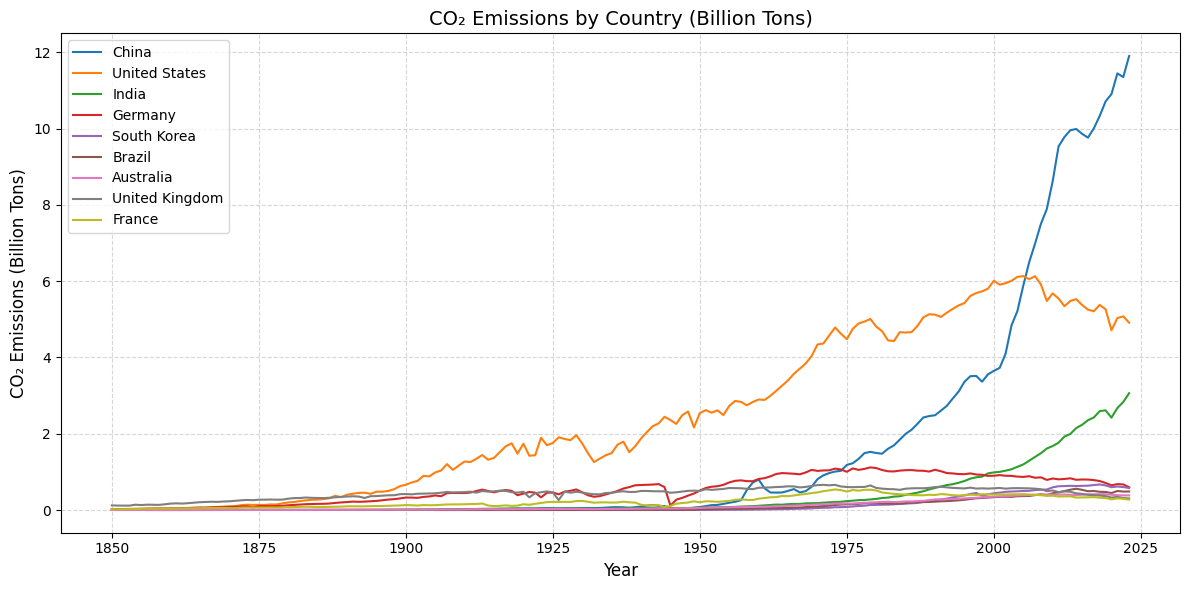

In [ ]:
# 주요 국가 선택
selected_countries = [
    'China', 'United States', 'India', 'Germany',
    'South Korea', 'Brazil', 'Australia',
    'United Kingdom', 'France'
]

# 데이터 필터링
filtered_data = data[data['Entity'].isin(selected_countries)]

# 시각화를 위해 데이터를 정렬
filtered_data = filtered_data.sort_values(by=['Entity', 'Year'])

# 시각화
plt.figure(figsize=(12, 6))
for country in selected_countries:
    country_data = filtered_data[filtered_data['Entity'] == country]
    plt.plot(
        country_data['Year'],
        country_data['Annual CO₂ emissions'] / 1e9,  # 단위를 billion으로 변경
        label=country
    )

# 그래프 스타일 설정
plt.title('CO₂ Emissions by Country (Billion Tons)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('CO₂ Emissions (Billion Tons)', fontsize=12)
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# 그래프 출력
plt.show()

In [ ]:
!pip install pandas matplotlib statsmodels prophet

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmph2esapfe/cqcfg2y1.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmph2esapfe/116bsofz.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=66939', 'data', 'file=/tmp/tmph2esapfe/cqcfg2y1.json', 'init=/tmp/tmph2esapfe/116bsofz.json', 'output', 'file=/tmp/tmph2esapfe/prophet_model7_tehilh/prophet_model-20241206151438.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
15:14:38 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:14:39 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.10/dist-packages/

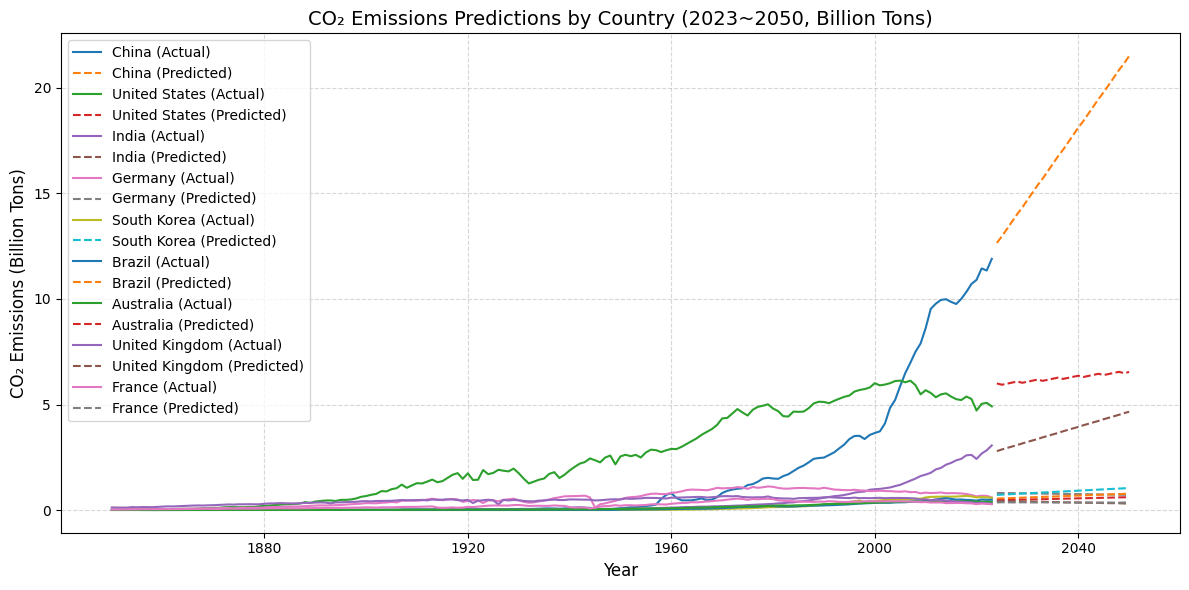

In [ ]:
from prophet import Prophet

# 주요 국가들만 필터링
filtered_data = data[data['Entity'].isin(selected_countries)]

# 'Year'를 datetime 형식으로 변환
filtered_data['Year'] = pd.to_datetime(filtered_data['Year'], format='%Y')

# 국가별 예측 데이터 저장
forecasts = {}

for country in selected_countries:
    country_data = filtered_data[filtered_data['Entity'] == country][['Year', 'Annual CO₂ emissions']]
    country_data = country_data.rename(columns={'Year': 'ds', 'Annual CO₂ emissions': 'y'})

    # Prophet 모델 초기화 및 학습
    model = Prophet(interval_width=0)  # 불확실성 제거
    model.fit(country_data)

    # 2050년까지 예측
    future = model.make_future_dataframe(periods=(2050 - country_data['ds'].dt.year.max()), freq='Y')
    forecast = model.predict(future)

    # 예측 데이터 저장
    forecasts[country] = forecast

# 시각화: 국가별 예측 데이터
plt.figure(figsize=(12, 6))
for country in selected_countries:
    forecast = forecasts[country]
    # 실제 데이터
    actual_data = filtered_data[filtered_data['Entity'] == country]
    plt.plot(
        actual_data['Year'],
        actual_data['Annual CO₂ emissions'] / 1e9,  # 단위를 billion으로 변환
        linestyle='-', label=f'{country} (Actual)'
    )
    # 예측 데이터
    forecast_after_actual = forecast[forecast['ds'] > actual_data['Year'].max()]
    plt.plot(
        forecast_after_actual['ds'],
        forecast_after_actual['yhat'] / 1e9,  # 단위를 billion으로 변환
        linestyle='--', label=f'{country} (Predicted)'
    )

# 그래프 스타일 설정
plt.title('CO₂ Emissions Predictions by Country (2023~2050, Billion Tons)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('CO₂ Emissions (Billion Tons)', fontsize=12)
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# 그래프 출력
plt.show()


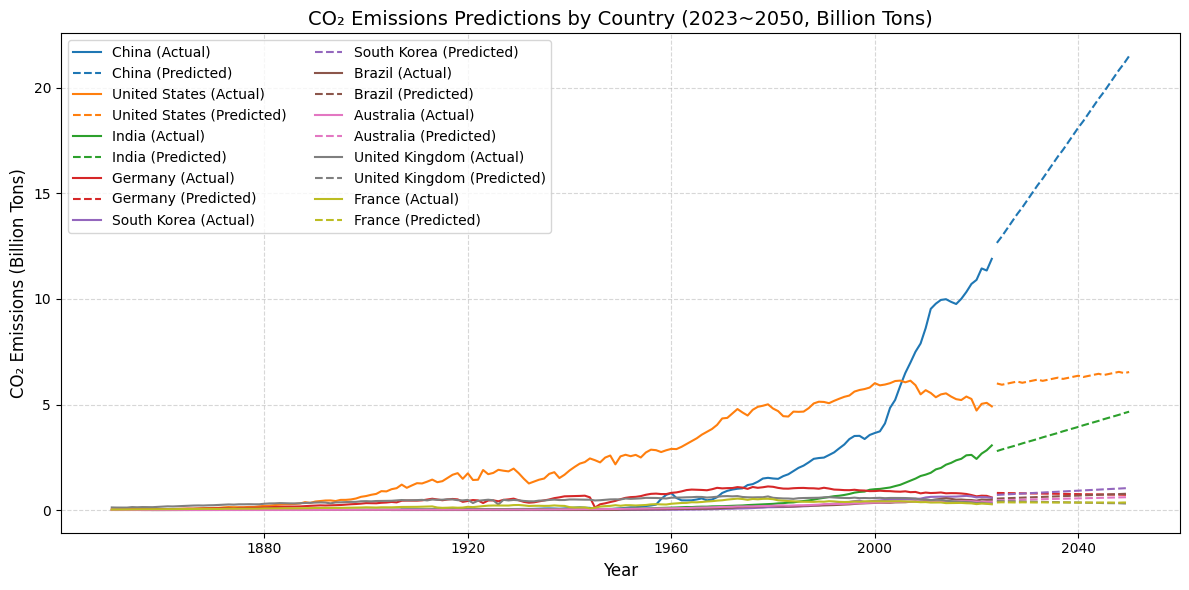

In [ ]:

import matplotlib.colors as mcolors

# 색상 설정
color_palette = list(mcolors.TABLEAU_COLORS.values())

# 시각화: 국가별 예측 데이터
plt.figure(figsize=(12, 6))
for i, country in enumerate(selected_countries):
    forecast = forecasts[country]
    actual_data = filtered_data[filtered_data['Entity'] == country]

    # 실제 데이터
    plt.plot(
        actual_data['Year'],
        actual_data['Annual CO₂ emissions'] / 1e9,  # 단위를 billion으로 변환
        linestyle='-', label=f'{country} (Actual)', color=color_palette[i]
    )
    # 예측 데이터
    forecast_after_actual = forecast[forecast['ds'] > actual_data['Year'].max()]
    plt.plot(
        forecast_after_actual['ds'],
        forecast_after_actual['yhat'] / 1e9,  # 단위를 billion으로 변환
        linestyle='--', label=f'{country} (Predicted)', color=color_palette[i]
    )

# 그래프 스타일 설정
plt.title('CO₂ Emissions Predictions by Country (2023~2050, Billion Tons)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('CO₂ Emissions (Billion Tons)', fontsize=12)
plt.legend(fontsize=10, loc='upper left', ncol=2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# 그래프 출력
plt.show()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


<Figure size 1600x3600 with 0 Axes>

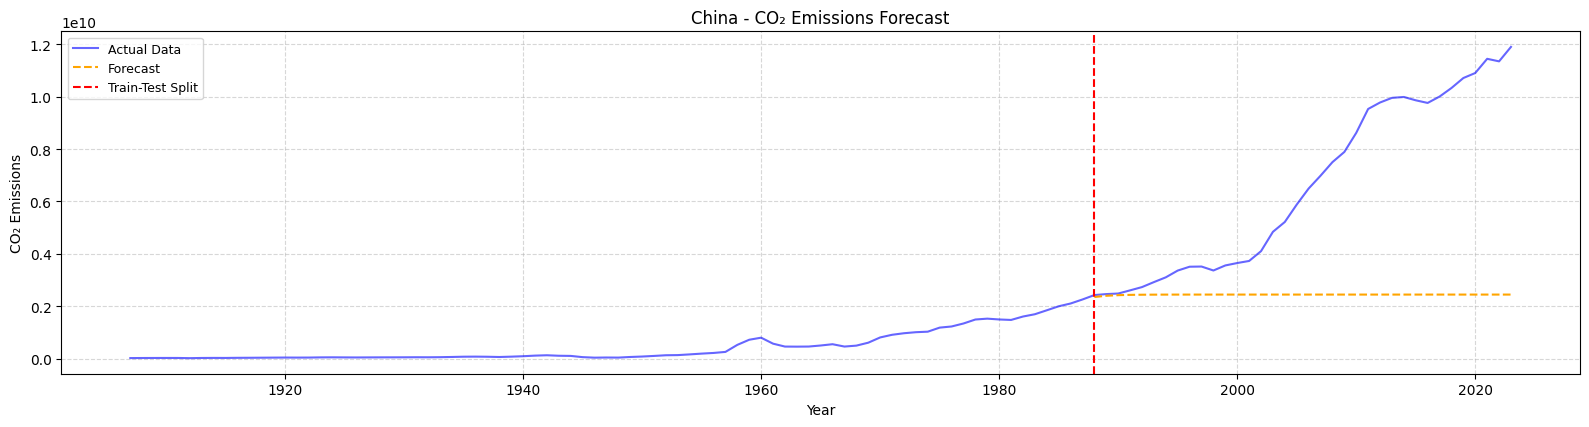

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA paramete

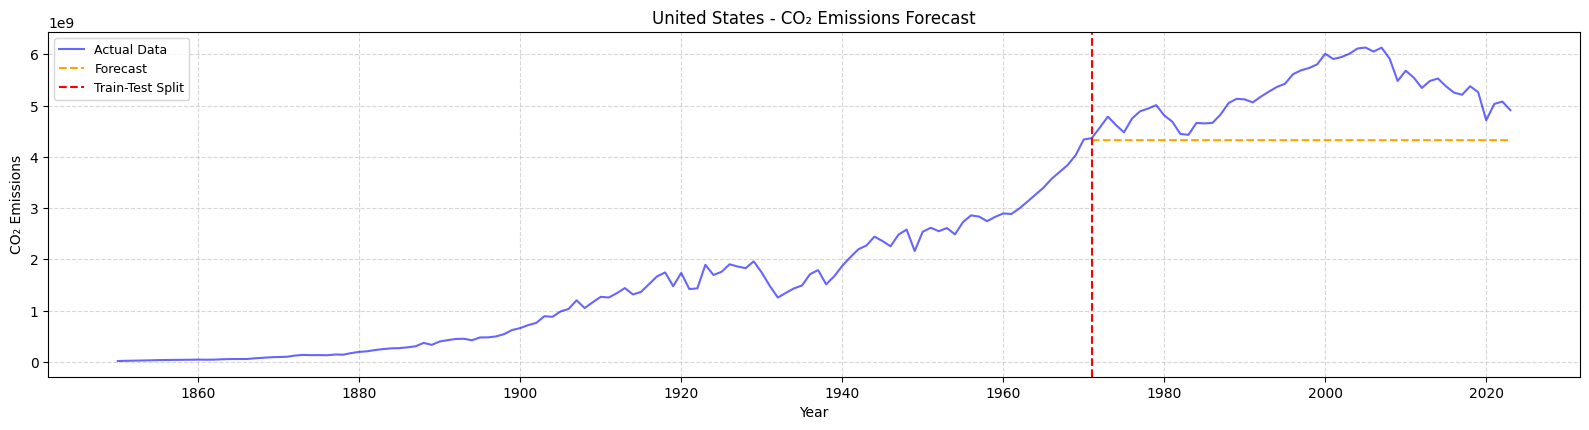

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/u

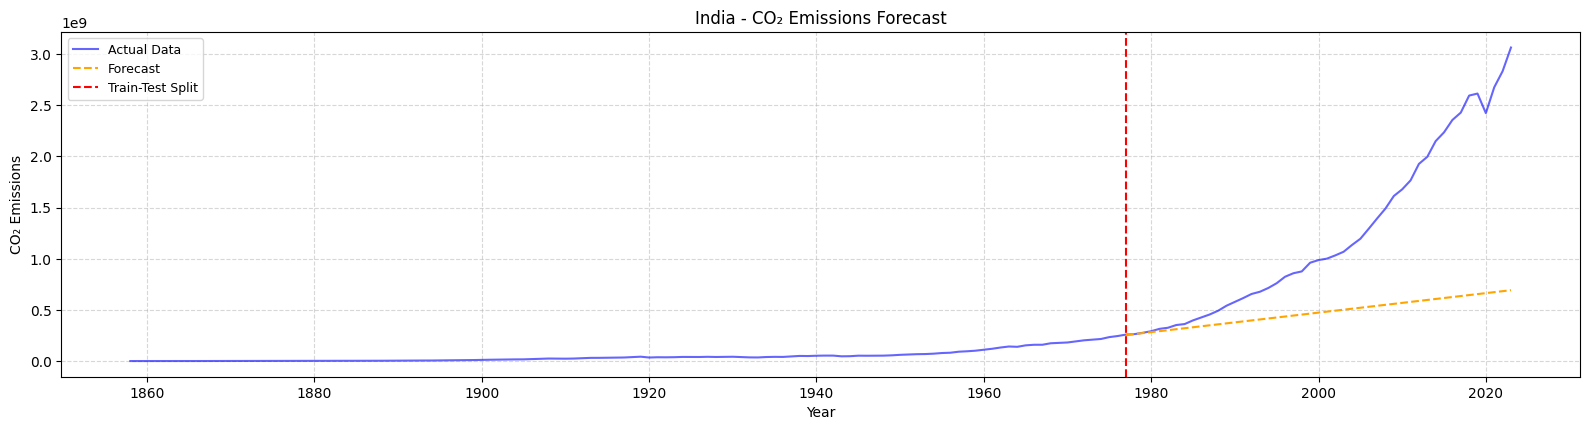

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


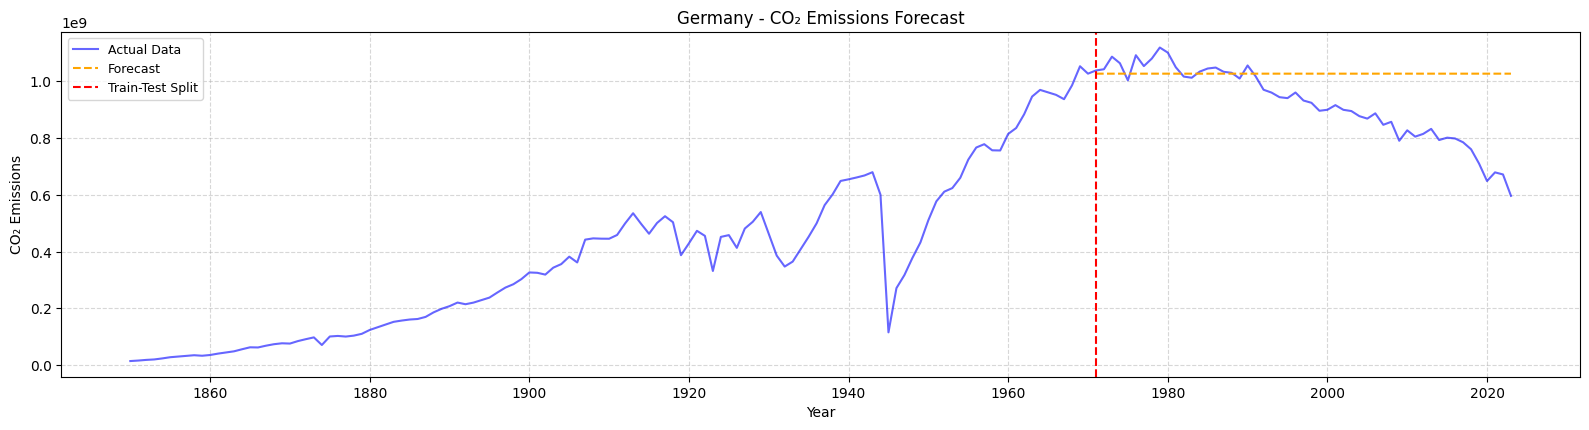

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/u

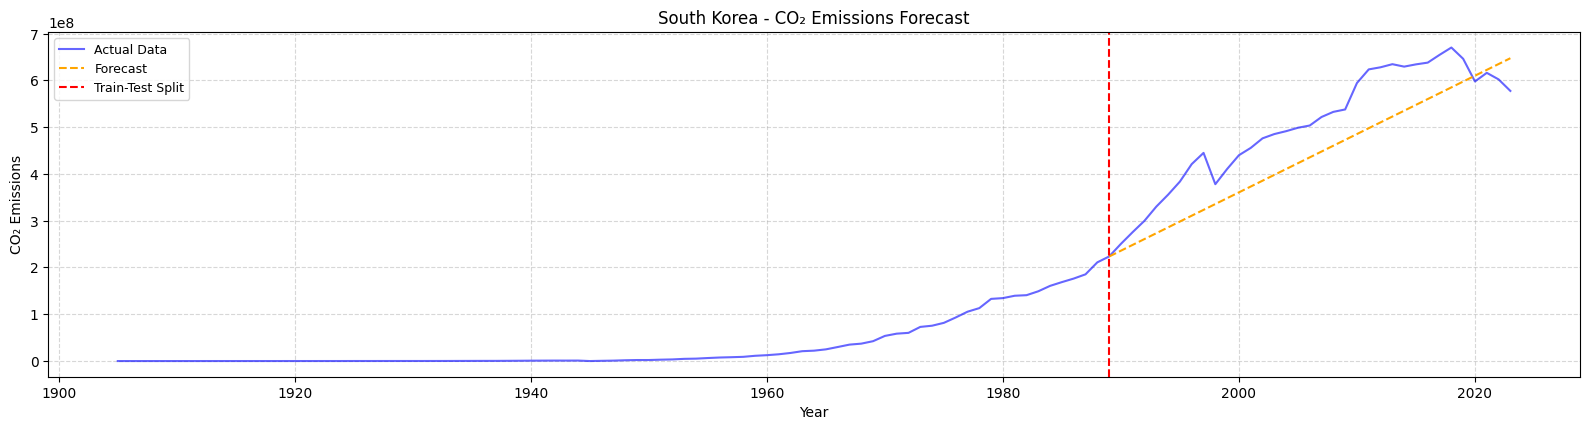

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


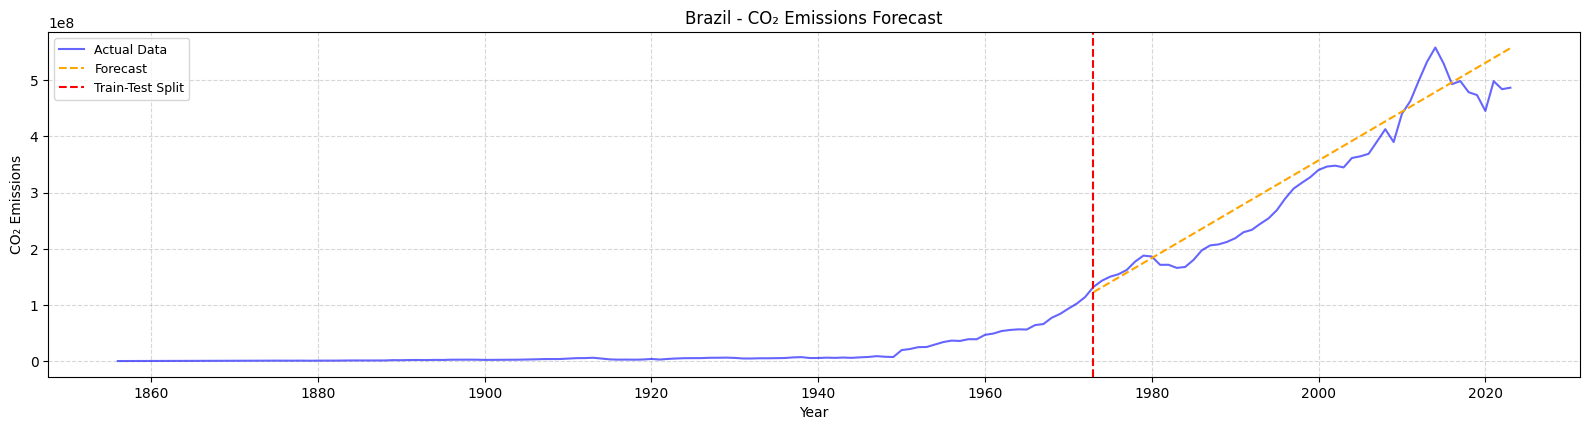

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


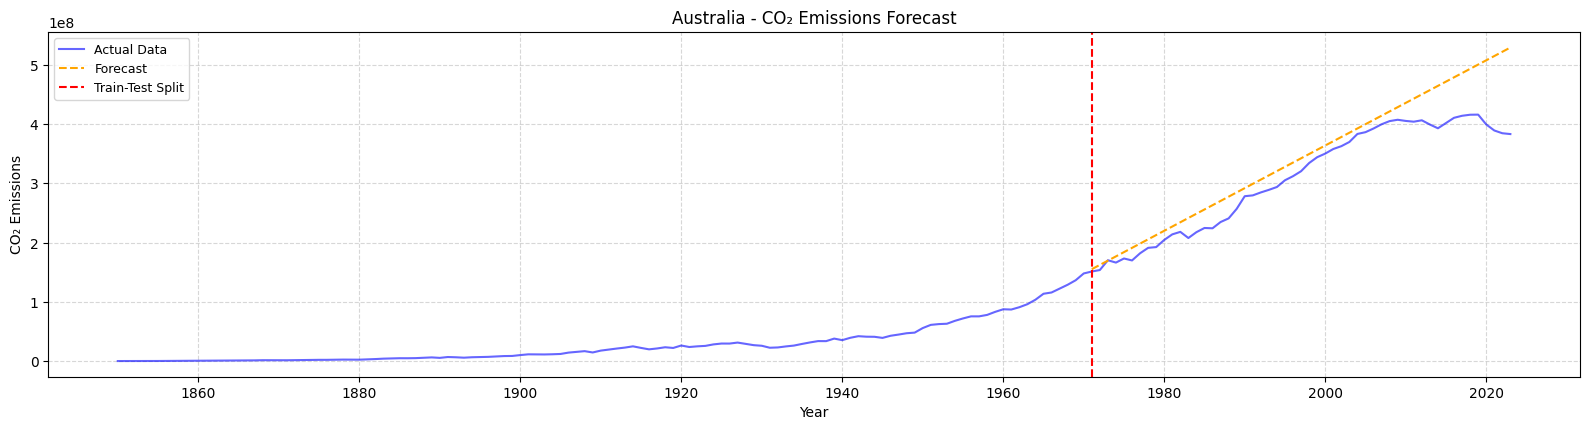

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


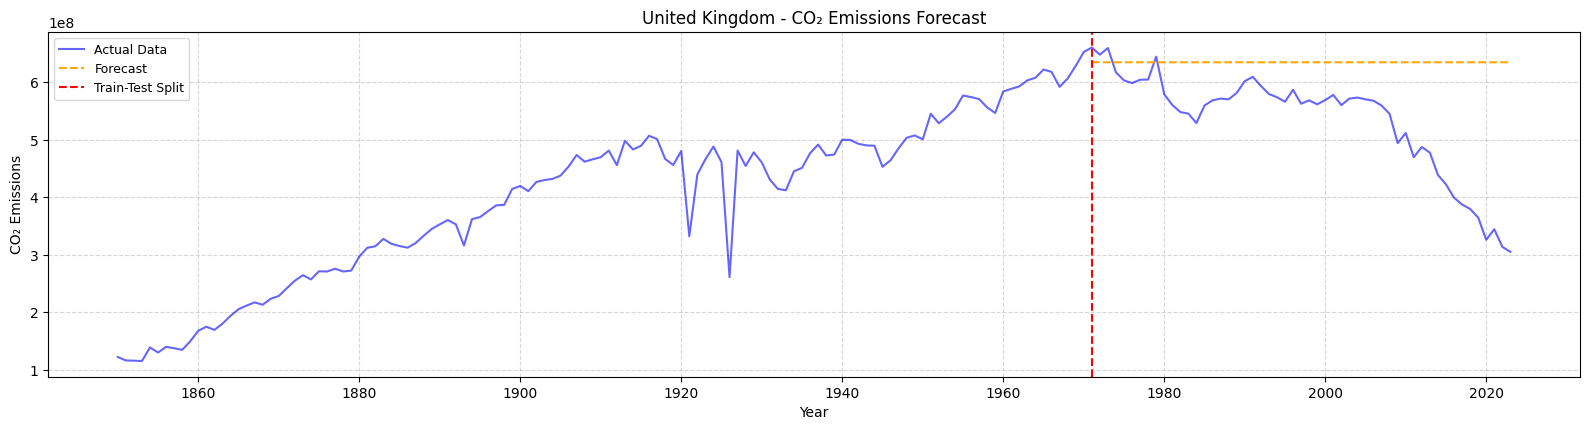

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


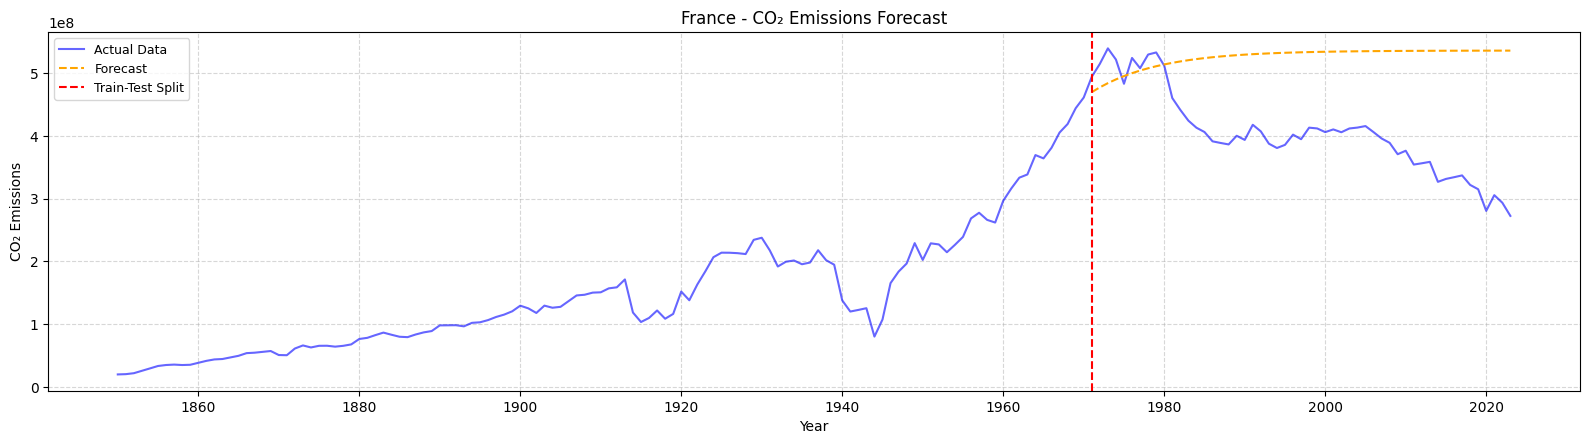

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 각 국가별로 별도 그래프로 시각화
scores = []
num_countries = len(selected_countries)
plt.figure(figsize=(16, 4 * num_countries))

for i, country in enumerate(selected_countries):
    # 각 국가 데이터 필터링
    plt.figure(figsize=(16, 4 * num_countries))
    country_data = filtered_data[filtered_data['Entity'] == country]
    country_data = country_data.groupby('Year')['Annual CO₂ emissions'].sum().reset_index()

    # 시계열 데이터 준비
    time_series = country_data.set_index('Year')['Annual CO₂ emissions']

    # 학습 및 테스트 데이터 분리 (70% 학습, 30% 테스트)
    train_size = int(len(time_series) * 0.7)
    train_data, test_data = time_series[:train_size], time_series[train_size:]

    # ARIMA 모델 학습 및 예측
    plt.subplot(num_countries, 1, i + 1)
    try:
        model = ARIMA(train_data, order=(1, 1, 1))
        fitted_model = model.fit()
        forecast = fitted_model.forecast(steps=len(test_data))

        # RMSE와 MAPE 계산
        rmse = np.sqrt(mean_squared_error(test_data, forecast))
        mape = np.mean(np.abs((test_data - forecast) / test_data)) * 100
        scores.append((country, rmse, mape))

        # 결과 시각화
        plt.plot(time_series.index, time_series, label='Actual Data', color='blue', alpha=0.6)
        plt.plot(test_data.index, forecast, label='Forecast', color='orange', linestyle='--')
        plt.axvline(x=test_data.index[0], color='red', linestyle='--', label='Train-Test Split')

    except Exception as e:
        print(f"ARIMA 모델 실패 ({country}): {e}")
        scores.append((country, None, None))  # 실패한 경우에도 빈 값을 추가

    # 그래프 스타일 설정
    plt.title(f'{country} - CO₂ Emissions Forecast', fontsize=12)
    plt.xlabel('Year', fontsize=10)
    plt.ylabel('CO₂ Emissions', fontsize=10)
    plt.legend(fontsize=9)
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()




In [ ]:
# 결과를 데이터프레임으로 출력
scores_df = pd.DataFrame(scores, columns=['Country', 'RMSE', 'MAPE'])
print(scores_df)

          Country          RMSE       MAPE
0           China  5.277102e+09  50.215379
1   United States  1.040527e+09  16.614068
2           India  1.021789e+09        NaN
3         Germany  1.665106e+08  15.842561
4     South Korea  7.753785e+07        NaN
5          Brazil  3.934028e+07  11.712638
6       Australia  4.859341e+07  10.840116
7  United Kingdom  1.356292e+08  23.947909
8          France  1.447135e+08  35.405716


<ipython-input-37-c7df7bc08fd6>:19: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  forecast_years = pd.date_range(start="2024-01-01", periods=26, freq="Y")
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
<ipython-input-37-c7df7bc08fd6>:19: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  forecast_years = pd.date_range(s

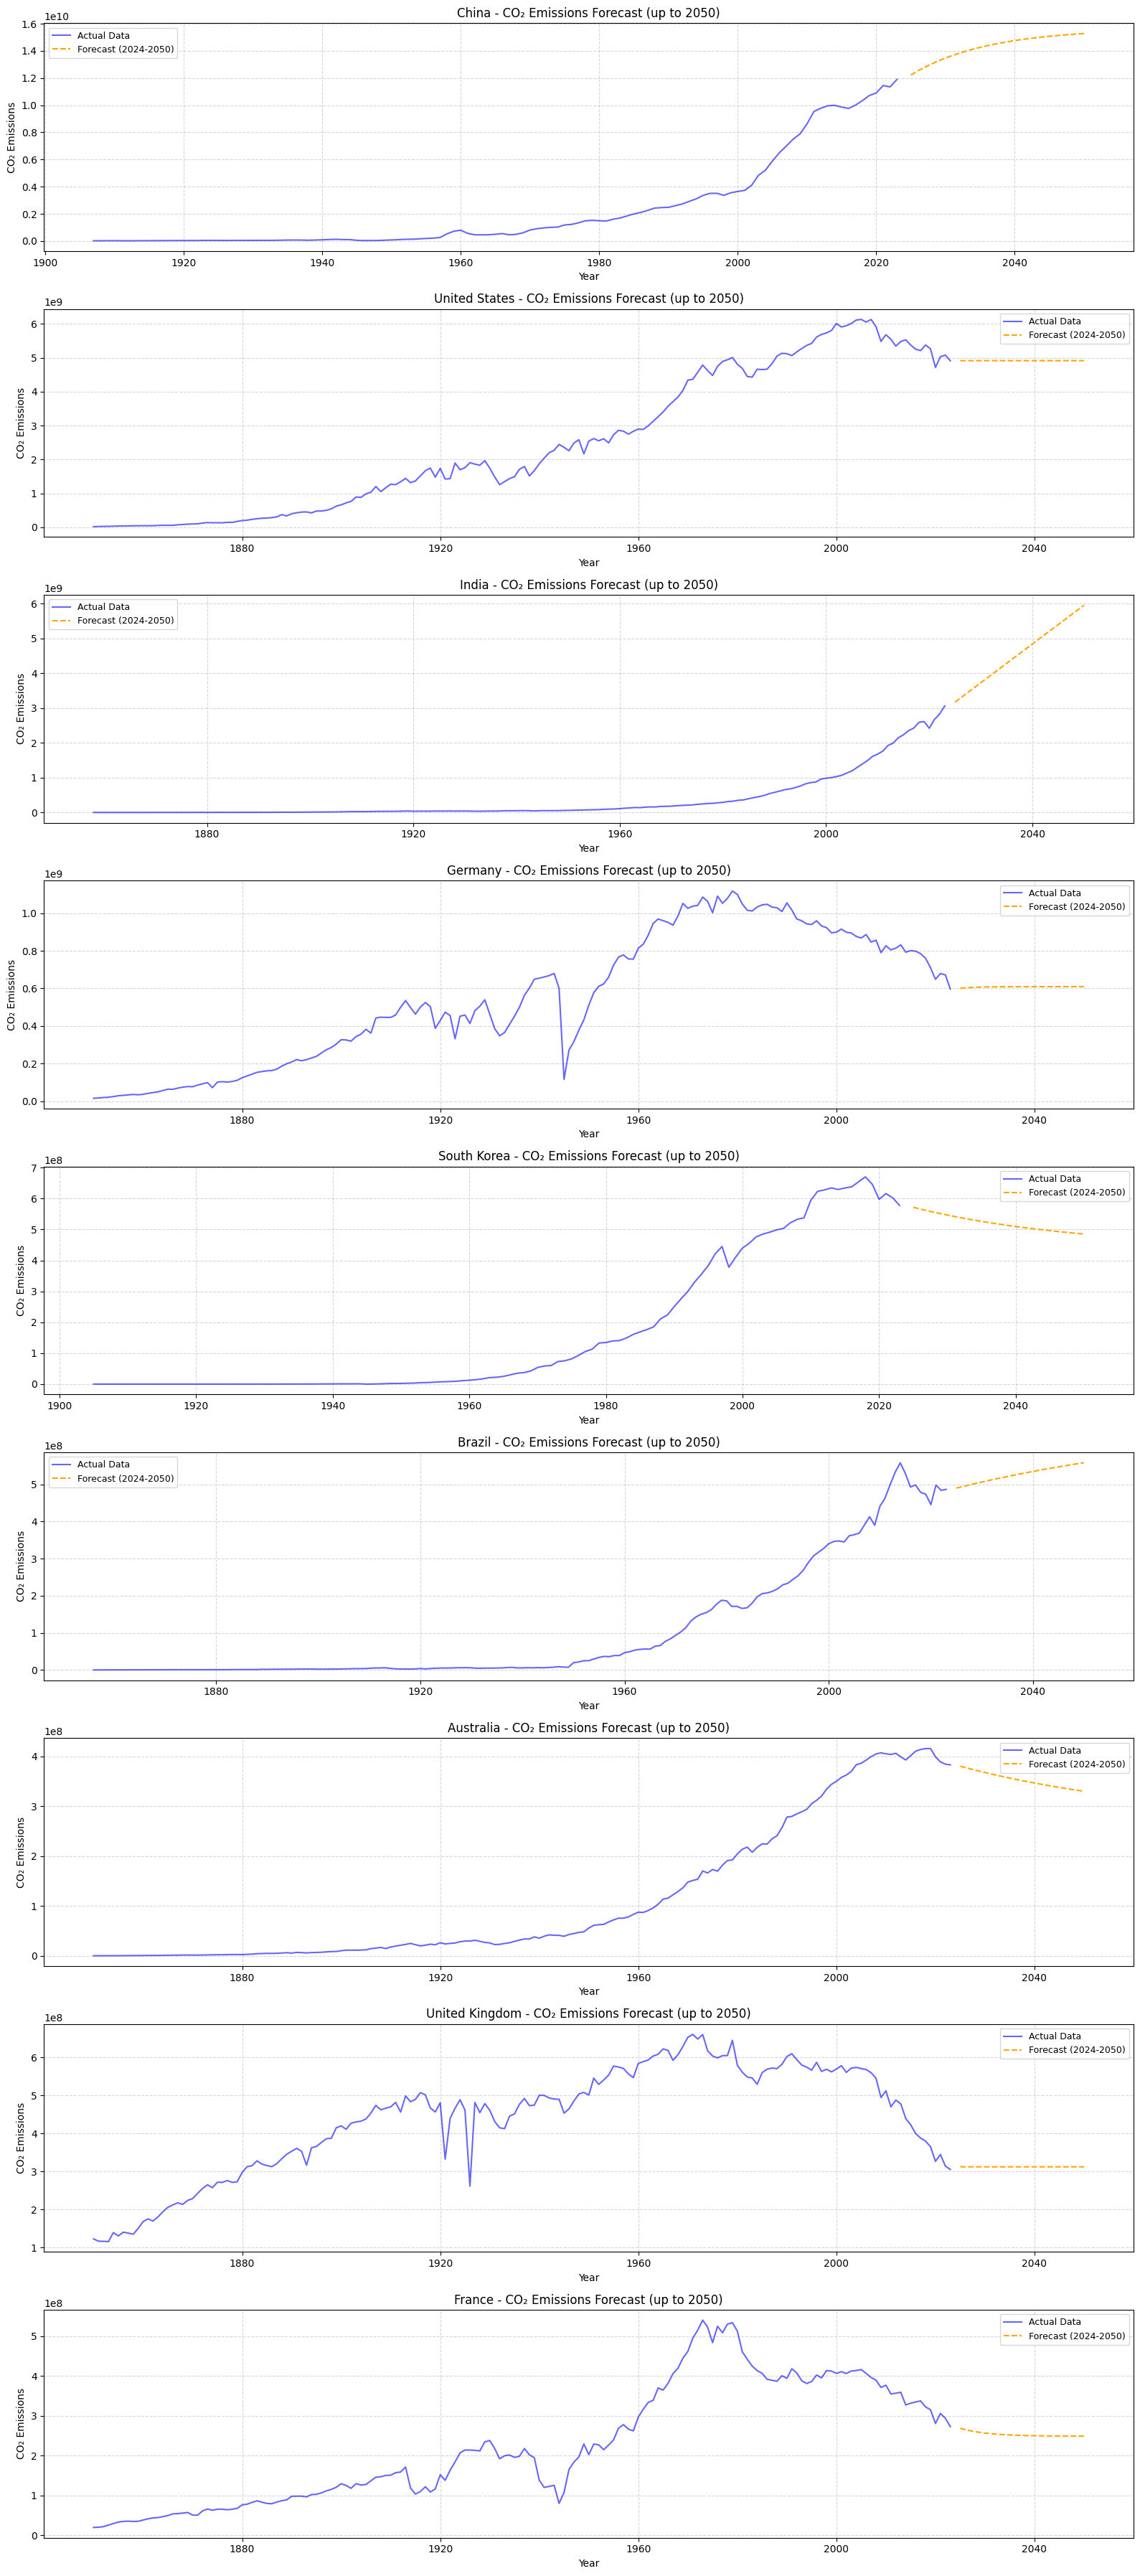

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# 각 국가별로 2024년도까지의 데이터로 학습하여 2050년도까지 예측하고 시각화
num_countries = len(selected_countries)
plt.figure(figsize=(16, 4 * num_countries))

for i, country in enumerate(selected_countries):
    # 각 국가 데이터 필터링
    country_data = filtered_data[filtered_data['Entity'] == country]
    country_data = country_data.groupby('Year')['Annual CO₂ emissions'].sum().reset_index()

    # 시계열 데이터 준비
    time_series = country_data.set_index('Year')['Annual CO₂ emissions']

    # 학습 및 예측 데이터
    forecast_years = pd.date_range(start="2024-01-01", periods=26, freq="Y")

    # 그래프 설정
    plt.subplot(num_countries, 1, i + 1)
    try:
        # ARIMA 모델 학습
        model = ARIMA(time_series, order=(1, 1, 1))
        fitted_model = model.fit()

        # 2050년까지 예측
        forecast = fitted_model.forecast(steps=len(forecast_years))

        # 예측 결과 병합
        forecast_series = pd.Series(forecast.values, index=forecast_years)


        # 결과 시각화
        plt.plot(time_series.index, time_series, label='Actual Data', color='blue', alpha=0.6)
        plt.plot(forecast_series.index, forecast_series, label='Forecast (2024-2050)', color='orange', linestyle='--')

        # X축 범위 설정
        # plt.xlim(1900, 2050)  # 1900년부터 2050년까지 표시

    except Exception as e:
        print(f"ARIMA 모델 실패 ({country}): {e}")

    # 그래프 스타일 설정
    plt.title(f'{country} - CO₂ Emissions Forecast (up to 2050)', fontsize=12)
    plt.xlabel('Year', fontsize=10)
    plt.ylabel('CO₂ Emissions', fontsize=10)
    plt.legend(fontsize=9)
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
